# SITCOM for Super-Resolution and Inpainting

This notebook is converted from `notebook-for-sr-inpainting.py` and organized for interactive use.

Workflow:
1. Load configs and runtime settings
2. Preview one image under SR and Inpainting measurements
3. Run SITCOM for both tasks with progress bars
4. Compare `Original | Measurement | SITCOM Recon` for both tasks


In [1]:
from pathlib import Path
import os
import sys
import yaml

def locate_sitcom_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'configs').exists() and (p / 'SITCOM.py').exists():
            return p
        if (p / 'SITCOM' / 'configs').exists() and (p / 'SITCOM' / 'SITCOM.py').exists():
            return p / 'SITCOM'
    raise FileNotFoundError('Could not locate SITCOM root from current working directory.')

repo = locate_sitcom_root(Path.cwd())
os.chdir(repo)
print('SITCOM root:', repo)
print('Python executable:', sys.executable)


SITCOM root: /egr/research-slim/hy2786/SITCOM
Python executable: /egr/research-slim/hy2786/miniconda3/envs/tada-dip/bin/python


In [12]:
# Runtime options
tasks = ['super_resolution', 'inpainting']
gpu_id = 3
use_cuda = True
run_now = True
# force_rerun = False
force_rerun = True

# Speed/quality trade-off
# num_steps = 4
num_steps = 30
# n_step = 5
n_step = 20 
learning_rate = 0.02
# learning_rate = 0.002
noiselevel = 0.05
# noiselevel = 0.005
random_seed = 42

config_paths = {
    'super_resolution': repo / 'configs' / 'super_resolution_config.yaml',
    'inpainting': repo / 'configs' / 'inpainting_config.yaml',
    'model': repo / 'configs' / 'model_config.yaml',
    'diffusion': repo / 'configs' / 'diffusion_config.yaml',
}

configs = {}
for name, path in config_paths.items():
    with open(path, 'r') as f:
        configs[name] = yaml.load(f, Loader=yaml.FullLoader)

for t in tasks:
    print(f"[{t}] data.root = {configs[t]['data']['root']}")
print('model_path =', configs['model']['model_path'])


[super_resolution] data.root = /egr/research-slim/hy2786/SITCOM/data/demo/
[inpainting] data.root = /egr/research-slim/hy2786/SITCOM/data/demo/
model_path = /egr/research-slim/hy2786/SITCOM/models/ffhq_10m.pt


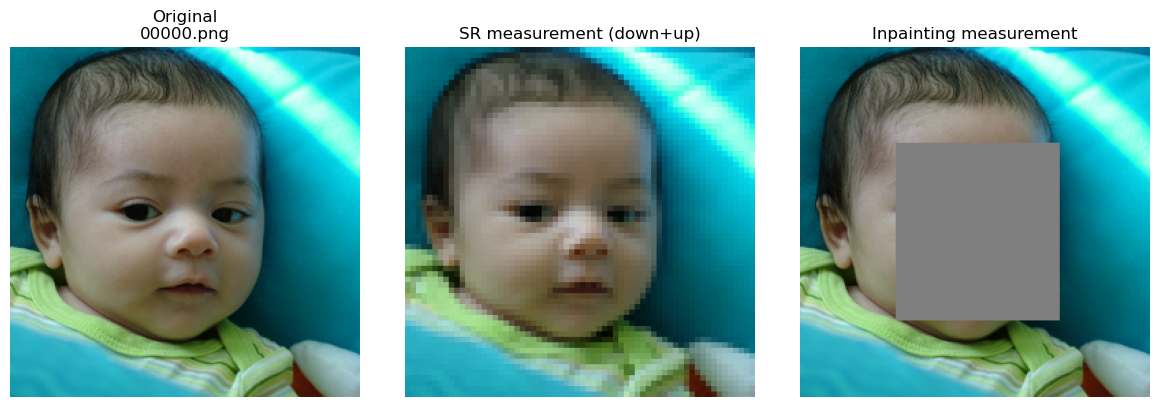

In [13]:
# Preview one image under SR and Inpainting measurements
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from guided_diffusion.measurements import get_operator

def to_tensor_256_rgb(img_path: Path):
    img = Image.open(img_path).convert('RGB').resize((256, 256))
    arr = np.array(img).astype(np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
    return t * 2 - 1

def t2img(t):
    t = t.detach().cpu().clamp(-1, 1)
    t = (t + 1) / 2
    return np.clip(t.squeeze(0).permute(1, 2, 0).numpy(), 0, 1)

sr_root = Path(configs['super_resolution']['data']['root'])
sr_images = sorted(sr_root.glob('**/*.png'))
if len(sr_images) == 0:
    raise FileNotFoundError(f'No PNG files found in: {sr_root}')

src_path = sr_images[0]
x = to_tensor_256_rgb(src_path)

sr_op = get_operator(device='cpu', **configs['super_resolution']['measurement']['operator'])
sr_y = sr_op.forward(x)
sr_meas = sr_op.transpose(sr_y).clamp(-1, 1)

inp_op = get_operator(device='cpu', **configs['inpainting']['measurement']['operator'])
mask = torch.ones(1, 3, 256, 256)
mask[:, :, 70:200, 70:190] = 0
inp_meas = inp_op.forward(x, mask=mask)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(t2img(x)); axs[0].set_title(f'Original\n{src_path.name}')
axs[1].imshow(t2img(sr_meas)); axs[1].set_title('SR measurement (down+up)')
axs[2].imshow(t2img(inp_meas)); axs[2].set_title('Inpainting measurement')
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [14]:
# Run SITCOM with progress bars
import subprocess
from glob import glob

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

task_cfg_map = {
    'super_resolution': 'configs/super_resolution_config.yaml',
    'inpainting': 'configs/inpainting_config.yaml',
}

def count_input_images(task_name: str) -> int:
    root = Path(configs[task_name]['data']['root'])
    return len(sorted(root.glob('**/*.png')))

def run_sitcom_task(task_name: str):
    save_dir = repo / 'results' / f'demo_{task_name}'
    save_dir.mkdir(parents=True, exist_ok=True)

    total_imgs = count_input_images(task_name)
    existing = sorted(save_dir.glob('result_image_*.png'))
    if (not force_rerun) and len(existing) >= total_imgs and total_imgs > 0:
        print(f'[{task_name}] skip run: found {len(existing)}/{total_imgs} existing outputs')
        return {'task': task_name, 'save_dir': save_dir, 'exit_code': 0}

    device = f'cuda:{gpu_id}' if use_cuda else 'cpu'
    cmd = [
        sys.executable, '-u', 'SITCOM_with_noise.py',
        '--model_config=configs/model_config.yaml',
        '--diffusion_config=configs/diffusion_config.yaml',
        f'--task_config={task_cfg_map[task_name]}',
        f'--gpu={gpu_id}',
        f'--device={device}',
        f'--learning_rate={learning_rate}',
        f'--num_steps={num_steps}',
        f'--n_step={n_step}',
        f'--noiselevel={noiselevel}',
        f'--random_seed={random_seed}',
        f'--save_path={save_dir}',
    ]

    print(f"\n===== [{task_name}] =====")
    print(' '.join(cmd))

    proc = subprocess.Popen(
        cmd,
        cwd=str(repo),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1,
    )

    pbar = None
    if tqdm is not None and total_imgs > 0:
        pbar = tqdm(total=total_imgs, desc=task_name, unit='img')

    stdout_tail = []
    for line in proc.stdout:
        line = line.rstrip('\n')
        if line:
            stdout_tail.append(line)
            stdout_tail = stdout_tail[-12:]
        if ('After diffusion PSNR' in line) and (pbar is not None):
            pbar.update(1)

    return_code = proc.wait()
    stderr_text = proc.stderr.read().strip()

    if pbar is not None:
        pbar.close()

    print(f'Exit code: {return_code}')
    if len(stdout_tail) > 0:
        print('\n--- STDOUT (tail) ---')
        print('\n'.join(stdout_tail))
    if stderr_text:
        print('\n--- STDERR (tail) ---')
        print('\n'.join(stderr_text.splitlines()[-12:]))

    return {'task': task_name, 'save_dir': save_dir, 'exit_code': return_code}

run_records = []
if run_now:
    for t in tasks:
        run_records.append(run_sitcom_task(t))
else:
    print('run_now=False -> skip execution; only visualization cells will use existing outputs.')



===== [super_resolution] =====
/egr/research-slim/hy2786/miniconda3/envs/tada-dip/bin/python -u SITCOM_with_noise.py --model_config=configs/model_config.yaml --diffusion_config=configs/diffusion_config.yaml --task_config=configs/super_resolution_config.yaml --gpu=3 --device=cuda:3 --learning_rate=0.02 --num_steps=30 --n_step=20 --noiselevel=0.05 --random_seed=42 --save_path=/egr/research-slim/hy2786/SITCOM/results/demo_super_resolution


super_resolution:   0%|          | 0/10 [00:00<?, ?img/s]

Exit code: 0

--- STDOUT (tail) ---
Processing time for image 5: 29.63 seconds
After diffusion PSNR: 25.316858291625977 dB
Processing time for image 6: 28.59 seconds
After diffusion PSNR: 30.360877990722656 dB
Processing time for image 7: 27.95 seconds
After diffusion PSNR: 30.62487030029297 dB
Processing time for image 8: 28.47 seconds
After diffusion PSNR: 28.327720642089844 dB
Processing time for image 9: 27.40 seconds
After diffusion PSNR: 30.02659797668457 dB
Processing time for image 10: 27.51 seconds
After diffusion PSNR: 30.454998016357422 dB

===== [inpainting] =====
/egr/research-slim/hy2786/miniconda3/envs/tada-dip/bin/python -u SITCOM_with_noise.py --model_config=configs/model_config.yaml --diffusion_config=configs/diffusion_config.yaml --task_config=configs/inpainting_config.yaml --gpu=3 --device=cuda:3 --learning_rate=0.02 --num_steps=30 --n_step=20 --noiselevel=0.05 --random_seed=42 --save_path=/egr/research-slim/hy2786/SITCOM/results/demo_inpainting


inpainting:   0%|          | 0/10 [00:00<?, ?img/s]

Exit code: 0

--- STDOUT (tail) ---
Processing time for image 5: 34.81 seconds
After diffusion PSNR: 25.932025909423828 dB
Processing time for image 6: 34.06 seconds
After diffusion PSNR: 23.350482940673828 dB
Processing time for image 7: 34.47 seconds
After diffusion PSNR: 25.450857162475586 dB
Processing time for image 8: 34.29 seconds
After diffusion PSNR: 24.667985916137695 dB
Processing time for image 9: 34.05 seconds
After diffusion PSNR: 23.54030990600586 dB
Processing time for image 10: 34.19 seconds
After diffusion PSNR: 24.50514030456543 dB


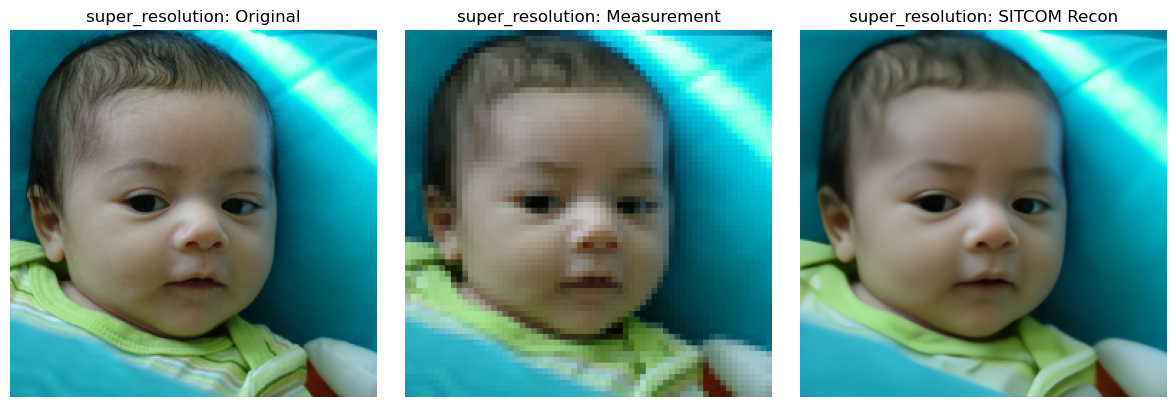

In [ ]:
# Compare for both tasks: Original | Measurement | SITCOM Recon
compare_tasks = ['super_resolution']
index_to_show = 0

fig, axs = plt.subplots(len(compare_tasks), 3, figsize=(12, 4 * len(compare_tasks)))
if len(compare_tasks) == 1:
    axs = [axs]

for r, tname in enumerate(compare_tasks):
    data_root = Path(configs[tname]['data']['root'])
    srcs = sorted(data_root.glob('**/*.png'))

    if len(srcs) == 0:
        for c in range(3):
            axs[r][c].text(0.5, 0.5, f'No PNG in\n{data_root}', ha='center', va='center')
            axs[r][c].axis('off')
        continue

    idx = min(index_to_show, len(srcs) - 1)
    x = to_tensor_256_rgb(srcs[idx])
    op = get_operator(device='cpu', **configs[tname]['measurement']['operator'])

    if tname == 'super_resolution':
        y = op.forward(x)
        meas = op.transpose(y).clamp(-1, 1)
    else:
        mask = torch.ones(1, 3, 256, 256)
        mask[:, :, 70:200, 70:190] = 0
        meas = op.forward(x, mask=mask)

    out_dir = repo / 'results' / f'demo_{tname}'
    recon_path = out_dir / f'result_image_{idx}.png'

    axs[r][0].imshow(t2img(x))
    axs[r][0].set_title(f'{tname}: Original')
    axs[r][1].imshow(t2img(meas))
    axs[r][1].set_title(f'{tname}: Measurement')

    if recon_path.exists():
        axs[r][2].imshow(Image.open(recon_path).convert('RGB'))
        axs[r][2].set_title(f'{tname}: SITCOM Recon')
    else:
        axs[r][2].text(0.5, 0.5, f'Missing\n{recon_path.name}', ha='center', va='center')
        axs[r][2].set_title(f'{tname}: SITCOM Recon')

    for c in range(3):
        axs[r][c].axis('off')

plt.tight_layout()
plt.show()
## add psnr to show the quality of the reconstruction, make sure mention the dataset used(public or private)⚠️!!!